In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Ruta completa del archivo en tu PC
file_path = r"C:\Users\57305\Documents\FTZ_model_2.0\simulations\ga_benchmark\results\FTZ_EvoBench_Test__20251011_095406\aggregates\results_df_edges.csv"

# Leer el CSV
df = pd.read_csv(file_path)

# Mostrar columnas relevantes
cols = ["algo", "env_id", "num_edges", "runtime_sec", "evals_total", "time_to_best", "time_per_eval"]
tabla = df[cols].sort_values("time_to_best")

print("🧩 Tabla resumida de tiempos a mejor individuo:")
print(tabla.head(10))

🧩 Tabla resumida de tiempos a mejor individuo:
      algo       env_id  num_edges  runtime_sec  evals_total  time_to_best  \
333  joint    g10_low_1         10    34.610986         1800            50   
291   flat  g6_medium_2          7    32.084130         1800            50   
331  joint    g10_low_1         10    34.575428         1800            50   
567  joint     g6_low_2          6    31.646337         1800            50   
560  joint     g6_low_2          6    31.536211         1800            50   
561  joint     g6_low_2          6    31.572695         1800            50   
562  joint     g6_low_2          6    31.803144         1800            50   
292   flat  g6_medium_2          7    31.898605         1800            50   
270   flat     g6_low_2          6    31.583873         1800            50   
550  joint     g6_low_0          6    31.621830         1800            50   

     time_per_eval  
333       0.019228  
291       0.017825  
331       0.019209  
567       

In [85]:
# --- Nuevas métricas de eficiencia temporal ---

# 1. Tiempo en segundos hasta el mejor individuo (estimado)
df["time_to_best_sec"] = df["time_to_best"] * df["time_per_eval"]

# 2. Fracción del total de evaluaciones que tomó alcanzar el mejor individuo
df["fraction_to_best"] = df["time_to_best"] / df["evals_total"]

# 3. Confirmación rápida de las nuevas columnas
df[["algo", "env_id", "time_to_best", "evals_total", "time_to_best_sec", "fraction_to_best"]].head(10)


,algo,env_id,time_to_best,evals_total,time_to_best_sec,fraction_to_best
0,flat,g10_high_0,1765,1800,79.662774,0.980556
1,flat,g10_high_0,1800,1800,80.039593,1.000000
2,flat,g10_high_0,1695,1800,76.344952,0.941667
3,flat,g10_high_0,1450,1800,65.135258,0.805556
4,flat,g10_high_0,1800,1800,80.700566,1.000000
5,flat,g10_high_0,1660,1800,74.440025,0.922222
6,flat,g10_high_0,1695,1800,75.757565,0.941667
7,flat,g10_high_0,1625,1800,72.613450,0.902778
8,flat,g10_high_1,890,1800,24.912369,0.494444
9,flat,g10_high_1,1170,1800,32.741242,0.650000


In [86]:
# Calcular densidad real del DAG (sin bucles)
df["real_density"] = df["num_edges"] / (df["N"] * (df["N"] - 1) / 2)

In [87]:
import os
import json
import networkx as nx
import pandas as pd

# Carpeta donde están los grafos JSON
graph_dir = r"C:\Users\57305\Documents\FTZ_model_2.0\simulations\ga_benchmark\data\graphs"

# Diccionario temporal para almacenar real_depth por ID
depth_map = {}

for filename in os.listdir(graph_dir):
    if filename.endswith(".json"):
        path = os.path.join(graph_dir, filename)
        with open(path, "r") as f:
            data = json.load(f)

        graph_id = data.get("graph_id")
        edges = data.get("edges", [])

        # Crear grafo dirigido y calcular profundidad real (largo del camino más largo)
        G = nx.DiGraph()
        G.add_edges_from(edges)

        try:
            real_depth = nx.dag_longest_path_length(G)
        except nx.NetworkXNoPath:
            real_depth = 0  # grafo vacío o sin aristas

        depth_map[graph_id] = real_depth

# Crear un DataFrame auxiliar
df_depth = pd.DataFrame(list(depth_map.items()), columns=["env_id", "real_depth"])

# Hacer merge con tu DataFrame principal
df = df.merge(df_depth, on="env_id", how="left")

print(f"✅ Columna 'real_depth' agregada correctamente. Tamaño final del df: {df.shape}")
df[["env_id", "num_edges", "N", "real_depth"]].head()


✅ Columna 'real_depth' agregada correctamente. Tamaño final del df: (592, 32)


,env_id,num_edges,N,real_depth
0,g10_high_0,31,10,5
1,g10_high_0,31,10,5
2,g10_high_0,31,10,5
3,g10_high_0,31,10,5
4,g10_high_0,31,10,5


In [88]:
# Estadísticas descriptivas por algoritmo
print("\n📈 Estadísticas de 'time_to_best' por algoritmo:")
print(df.groupby("algo")["time_to_best"].describe()[["mean", "std", "min", "max"]])

# Correlaciones con otras variables
corr_vars = ["num_edges", "N", "real_density", "runtime_sec", "time_per_eval", "time_to_best","real_depth"]
print("\n🔗 Correlaciones con time_to_best:")
print(df[corr_vars].corr()["time_to_best"].sort_values(ascending=False))


📈 Estadísticas de 'time_to_best' por algoritmo:
              mean          std   min     max
algo                                         
flat   2034.898649  2003.126579  50.0  5350.0
joint  1527.280405  1811.383062  50.0  5350.0

🔗 Correlaciones con time_to_best:
time_to_best     1.000000
num_edges        0.903054
real_depth       0.705259
N                0.700053
runtime_sec      0.663222
time_per_eval    0.636424
real_density     0.255351
Name: time_to_best, dtype: float64


In [89]:
df["time_to_best"].unique()


array([1765, 1800, 1695, 1450, 1660, 1625,  890, 1170,  925,  820, 1135,
       1065, 1590, 1555,  155,  470,  225,  295,  400,  120,  365,   85,
        260,  575,  330,  995,  785, 1030,  680,  750,  645,  855, 1100,
       1205, 5070, 5350, 5210, 5280, 4860, 5140,  800,  590,  660,  520,
        730,  870, 1010,  310,  450, 1290, 1220, 2970, 3740, 3250, 3670,
       4020, 3600, 3880, 2690, 2760, 2830, 2480, 3110, 3390, 3180, 3530,
       2900, 3460, 5000, 4790, 4720, 1570, 1150, 1850, 1640, 1430, 1360,
       1080, 1780, 1500, 1990,  940, 4580, 2880, 3090, 3405, 3825, 2775,
       3510,   50,  190,  960,  435,  540,  715,  505, 4230, 4440, 4300,
       2270, 2130, 4160, 4930,  240,  380, 1920, 1710, 3950, 3810, 4650,
       3040, 3320, 2410, 2670, 2040, 2460, 2250, 1410, 1620])

In [90]:
df.columns

Index(['algo', 'env_id', 'seed', 'runtime_sec', 'evals_total', 'U_best',
       'curve_best', 'curve_mean', 'evals_cum', 'best_by_selectors',
       'pool_sizes', 'sizes', 'alphabet', 'N', 'density', 'max_depth',
       'price_file', 'SCR', 'SFI', 'RBS', 'time_to_best', 'diversity_initial',
       'diversity_final', 'delta_diversity', 'convergence_slope',
       'runtime_efficiency', 'num_edges', 'time_per_eval', 'time_to_best_sec',
       'fraction_to_best', 'real_density', 'real_depth'],
      dtype='object')

In [91]:
df["evals_total"].unique()


array([ 1800,  5350, 10650])

In [92]:
print("\n📈 Estadísticas de convergencia por algoritmo:")
stats = df.groupby("algo")[["time_to_best", "time_to_best_sec", "fraction_to_best"]].agg(["mean", "std", "min", "max"])
print(stats)



📈 Estadísticas de convergencia por algoritmo:
      time_to_best                        time_to_best_sec              \
              mean          std min   max             mean         std   
algo                                                                     
flat   2034.898649  2003.126579  50  5350       289.050695  659.215229   
joint  1527.280405  1811.383062  50  5350       279.825140  709.685336   

                             fraction_to_best                           
            min          max             mean       std       min  max  
algo                                                                    
flat   0.877217  2994.797970         0.465472  0.364506  0.027778  1.0  
joint  0.872020  3238.494438         0.330162  0.323868  0.027778  1.0  


In [93]:
corr_vars = ["num_edges", "N", "real_density","real_depth", "runtime_sec", "time_to_best", "time_to_best_sec", "fraction_to_best"]
print("\n🔗 Correlaciones con métricas de convergencia:")
print(df[corr_vars].corr()[["time_to_best", "time_to_best_sec", "fraction_to_best"]])



🔗 Correlaciones con métricas de convergencia:
                  time_to_best  time_to_best_sec  fraction_to_best
num_edges             0.903054          0.834202          0.833688
N                     0.700053          0.440703          0.549295
real_density          0.255351          0.381460          0.418721
real_depth            0.705259          0.735909          0.801219
runtime_sec           0.663222          0.995610          0.591777
time_to_best          1.000000          0.664618          0.918236
time_to_best_sec      0.664618          1.000000          0.610501
fraction_to_best      0.918236          0.610501          1.000000


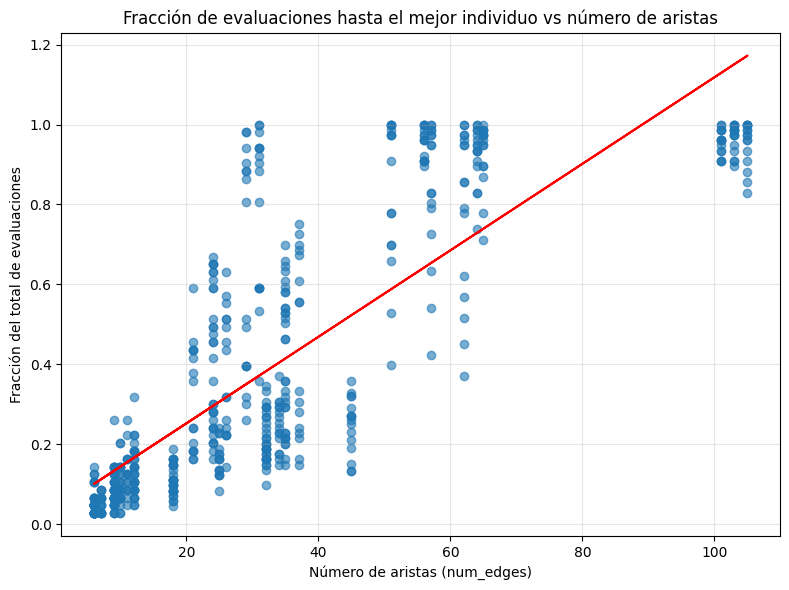

In [94]:
plt.figure(figsize=(8,6))
plt.scatter(df["num_edges"], df["fraction_to_best"], alpha=0.6)
m, b = np.polyfit(df["num_edges"], df["fraction_to_best"], 1)
plt.plot(df["num_edges"], m*df["num_edges"] + b, color="red")
plt.title("Fracción de evaluaciones hasta el mejor individuo vs número de aristas")
plt.xlabel("Número de aristas (num_edges)")
plt.ylabel("Fracción del total de evaluaciones")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


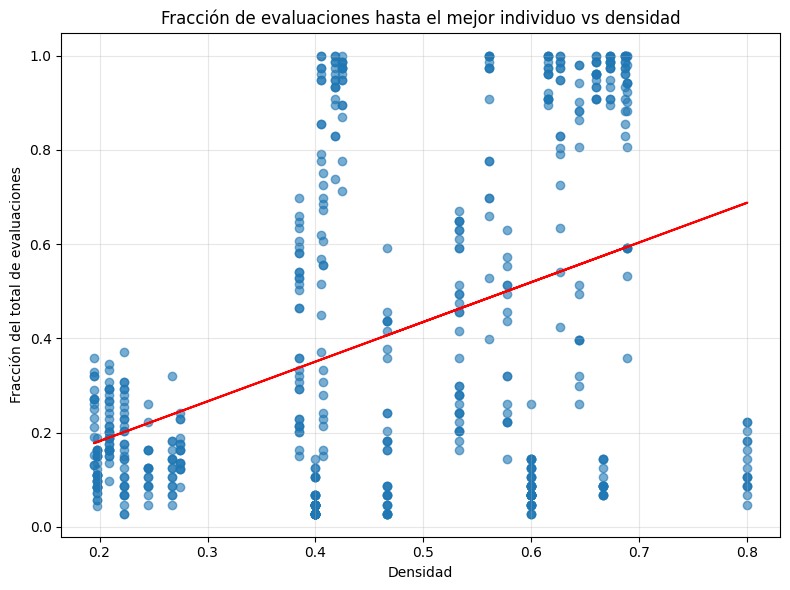

In [105]:
plt.figure(figsize=(8,6))
plt.scatter(df["real_density"], df["fraction_to_best"], alpha=0.6)
m, b = np.polyfit(df["real_density"], df["fraction_to_best"], 1)
plt.plot(df["real_density"], m*df["real_density"] + b, color="red")
plt.title("Fracción de evaluaciones hasta el mejor individuo vs densidad")
plt.xlabel("Densidad")
plt.ylabel("Fracción del total de evaluaciones")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\57305\AppData\Local\Temp\ipykernel_15296\3530066635.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=df["algo"].unique(), patch_artist=True,


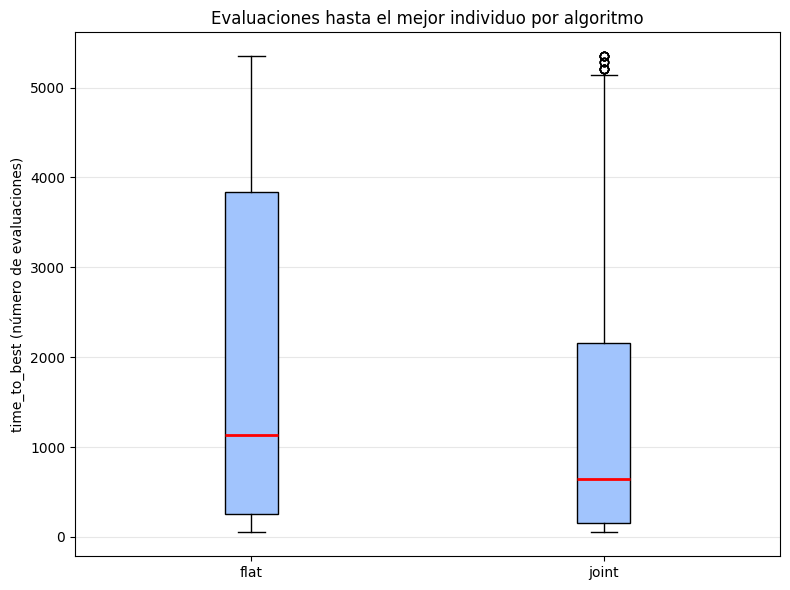

C:\Users\57305\AppData\Local\Temp\ipykernel_15296\3530066635.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=df["algo"].unique(), patch_artist=True,


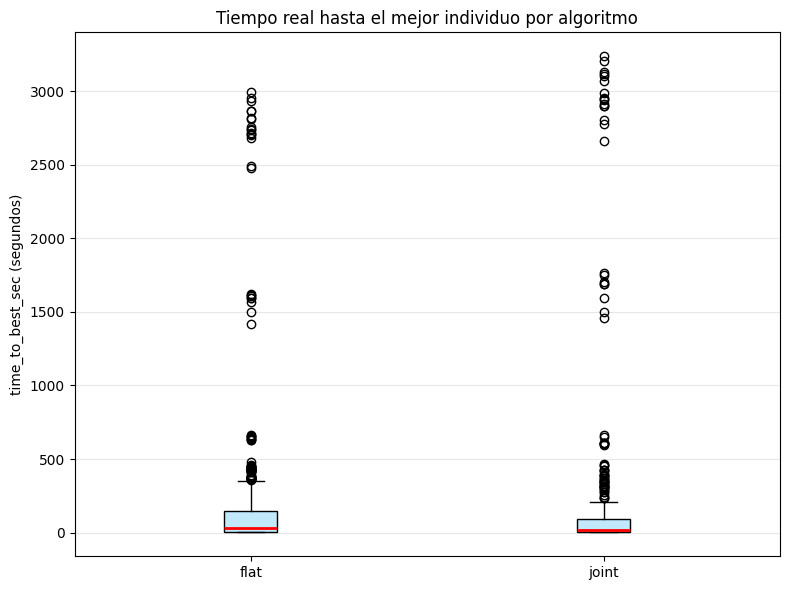

C:\Users\57305\AppData\Local\Temp\ipykernel_15296\3530066635.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=df["algo"].unique(), patch_artist=True,


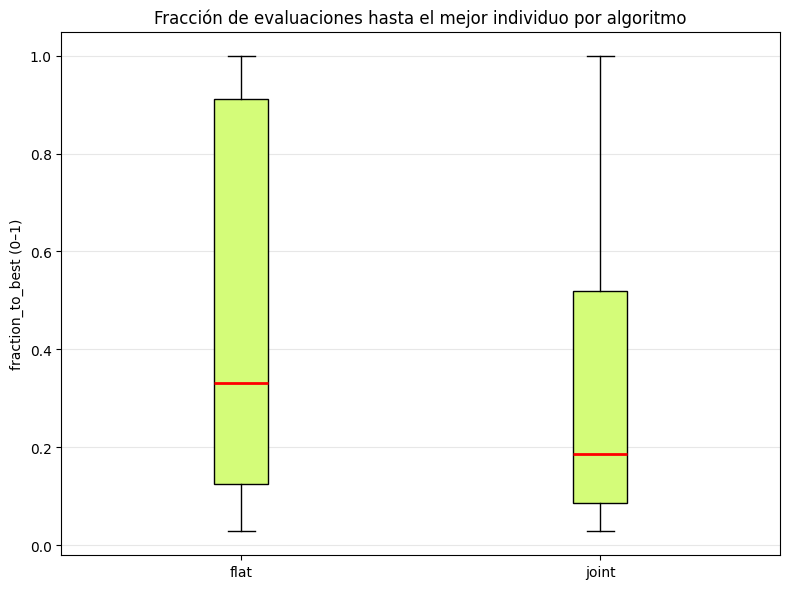

In [95]:
# Boxplot 1: número de evaluaciones hasta el mejor individuo
plt.figure(figsize=(8,6))
data = [df[df["algo"] == algo]["time_to_best"] for algo in df["algo"].unique()]
plt.boxplot(data, labels=df["algo"].unique(), patch_artist=True,
            boxprops=dict(facecolor="#a1c4fd", color="black"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Evaluaciones hasta el mejor individuo por algoritmo")
plt.ylabel("time_to_best (número de evaluaciones)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Boxplot 2: tiempo real hasta el mejor individuo
plt.figure(figsize=(8,6))
data = [df[df["algo"] == algo]["time_to_best_sec"] for algo in df["algo"].unique()]
plt.boxplot(data, labels=df["algo"].unique(), patch_artist=True,
            boxprops=dict(facecolor="#c2e9fb", color="black"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Tiempo real hasta el mejor individuo por algoritmo")
plt.ylabel("time_to_best_sec (segundos)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Boxplot 3: fracción del total usada para alcanzar el mejor
plt.figure(figsize=(8,6))
data = [df[df["algo"] == algo]["fraction_to_best"] for algo in df["algo"].unique()]
plt.boxplot(data, labels=df["algo"].unique(), patch_artist=True,
            boxprops=dict(facecolor="#d4fc79", color="black"),
            medianprops=dict(color="red", linewidth=2))
plt.title("Fracción de evaluaciones hasta el mejor individuo por algoritmo")
plt.ylabel("fraction_to_best (0–1)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [96]:
df["converged"] = (df["fraction_to_best"] < 0.90)
df["converged"].mean()


np.float64(0.8006756756756757)

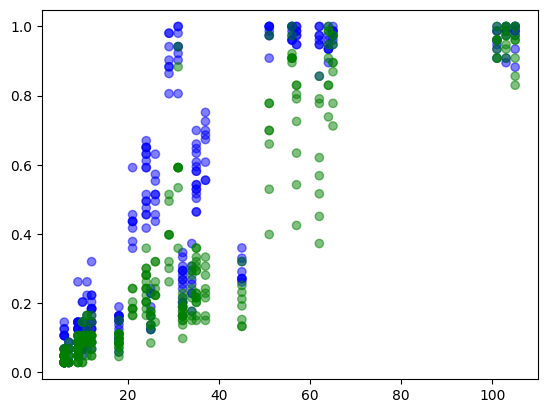

In [97]:
plt.scatter(df["num_edges"], df["fraction_to_best"], alpha=0.5, c=df["algo"].map({"flat": "blue", "joint": "green"}))


In [98]:
# 1. Evaluaciones restantes tras alcanzar el mejor individuo
df["remaining_evals"] = df["evals_total"] - df["time_to_best"]

# 2. Eficiencia temporal: fracción no usada dividida por el tiempo total
# mide cuánta fracción de búsqueda "ahorró" por segundo
df["efficiency"] = (1 - df["fraction_to_best"]) / df["runtime_sec"]

# Revisión rápida
df[["algo", "env_id", "num_edges", "time_to_best", "remaining_evals", "efficiency"]].head(10)
                                                                            


,algo,env_id,num_edges,time_to_best,remaining_evals,efficiency
0,flat,g10_high_0,31,1765,35,0.000239
1,flat,g10_high_0,31,1800,0,0.000000
2,flat,g10_high_0,31,1695,105,0.000720
3,flat,g10_high_0,31,1450,350,0.002405
4,flat,g10_high_0,31,1800,0,0.000000
5,flat,g10_high_0,31,1660,140,0.000964
6,flat,g10_high_0,31,1695,105,0.000725
7,flat,g10_high_0,31,1625,175,0.001209
8,flat,g10_high_1,24,890,910,0.010034
9,flat,g10_high_1,24,1170,630,0.006948


In [99]:
print("\n📊 Estadísticas por algoritmo:")
print(df.groupby("algo")[["remaining_evals", "efficiency"]].agg(["mean", "std", "min", "max"]))



📊 Estadísticas por algoritmo:
      remaining_evals                        efficiency                 \
                 mean          std min   max       mean       std  min   
algo                                                                     
flat      1731.317568  1683.069166   0  7875   0.010847  0.011307  0.0   
joint     2238.935811  1780.921576   0  9240   0.012508  0.011482  0.0   

                 
            max  
algo             
flat   0.030786  
joint  0.030970  


In [100]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Copia de seguridad
df_reg = df.copy()

# Asegurar tipos numéricos
df_reg["num_edges"] = pd.to_numeric(df_reg["num_edges"], errors="coerce")
df_reg["N"] = pd.to_numeric(df_reg["N"], errors="coerce")
df_reg["real_density"] = pd.to_numeric(df_reg["real_density"], errors="coerce")
df_reg["time_to_best"] = pd.to_numeric(df_reg["time_to_best"], errors="coerce")

# Variables explicativas
X = df_reg[["num_edges", "real_density", "N","real_depth"]]
X = sm.add_constant(pd.get_dummies(df_reg["algo"], drop_first=True).join(X))

# Variable dependiente
y = df_reg["time_to_best"]

# Ajuste del modelo
model = sm.OLS(y, X.astype(float)).fit()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:           time_to_best   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     620.2
Date:                Fri, 17 Oct 2025   Prob (F-statistic):          2.69e-231
Time:                        11:26:11   Log-Likelihood:                -4772.2
No. Observations:                 592   AIC:                             9556.
Df Residuals:                     586   BIC:                             9583.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1126.0026    300.991     -3.741   

In [101]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_check = X[["joint", "num_edges", "real_density", "N","real_depth"]].astype(float)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_check.columns
vif_data["VIF"] = [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
print(vif_data)


       Variable        VIF
0         joint   1.977852
1     num_edges   9.085693
2  real_density  17.007885
3             N   7.296739
4    real_depth  33.924906


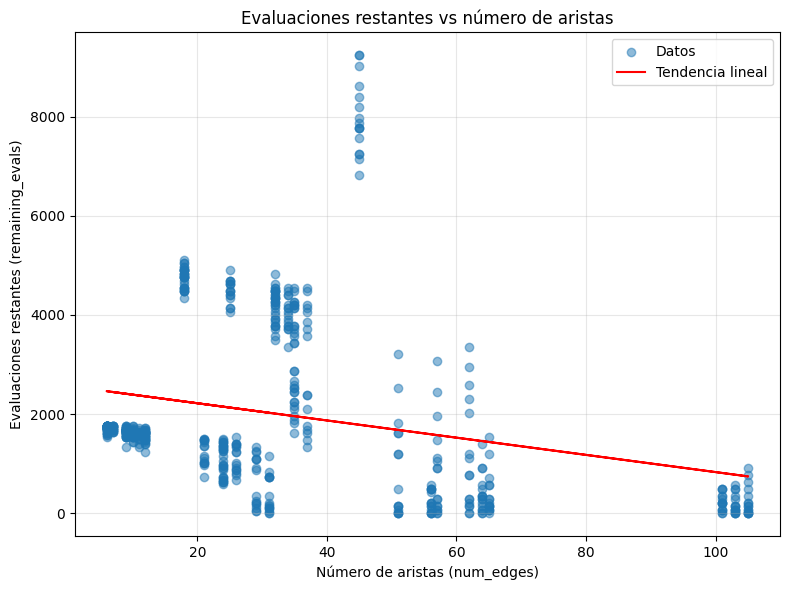

In [102]:
plt.figure(figsize=(8,6))
plt.scatter(df["num_edges"], df["remaining_evals"], alpha=0.5, label="Datos")
m, b = np.polyfit(df["num_edges"], df["remaining_evals"], 1)
plt.plot(df["num_edges"], m*df["num_edges"] + b, color="red", label="Tendencia lineal")
plt.title("Evaluaciones restantes vs número de aristas")
plt.xlabel("Número de aristas (num_edges)")
plt.ylabel("Evaluaciones restantes (remaining_evals)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [103]:
df["real_depth"].describe()


count    592.000000
mean       3.378378
std        1.422114
min        2.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        7.000000
Name: real_depth, dtype: float64

In [104]:
df["real_density"].describe()


count    592.000000
mean       0.455750
std        0.174294
min        0.194805
25%        0.274725
50%        0.424837
75%        0.600000
max        0.800000
Name: real_density, dtype: float64